# BasisAE demo

This notebook builds a small synthetic movie cube and fits the `comicsnet.BasisAE` background model with the sparse-mask loop.

The synthetic cube contains a smooth time-variable background plus a moving compact source.  The model sees one complete detector frame per optimization step and reconstructs each frame as a linear combination of detector-fixed basis images.


In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import astropy.io.fits as fits

from comicsnet import Config, BasisAE, fit

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

The array shape is `(time, y, x)`.  The size is intentionally small so
that the notebook runs quickly on CPU.

In [2]:
cube = fits.open('../data/demo.fits')[0].data
nz, ny, nx = cube.shape

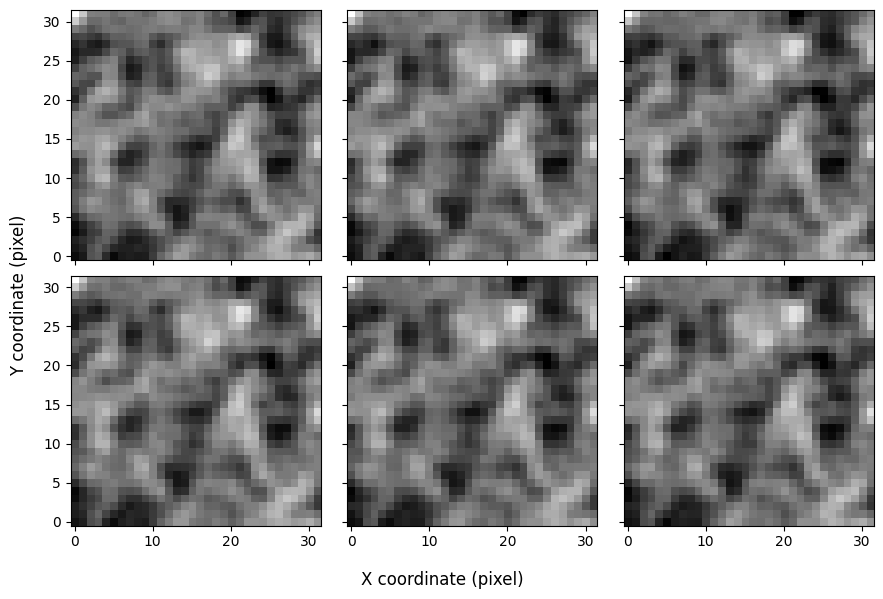

In [3]:
fig, axes = plt.subplots(
    2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
    ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit BasisAE

The model learns detector-fixed basis images and frame-wise
coefficients.


In [4]:
config = Config(
    outer_steps=5,
    inner_steps=20000,
    learning_rate=1.0e-4,
    beta=1.0e-4,
    threshold_sigma=2.0,
    erosion_size=3,
    dilation_size=5,
    seed=1,
)

model_key = jax.random.PRNGKey(2)
model = BasisAE(
    frame_shape=(ny, nx),
    basis_dim=1,
    hidden_dim=8,
    latent_dim=4,
    key=model_key,
)

result = fit(model, cube, config=config)

The trace of the loss function is illustrated below. The loss is computed on the full cube, but the model sees only one frame per optimization step.

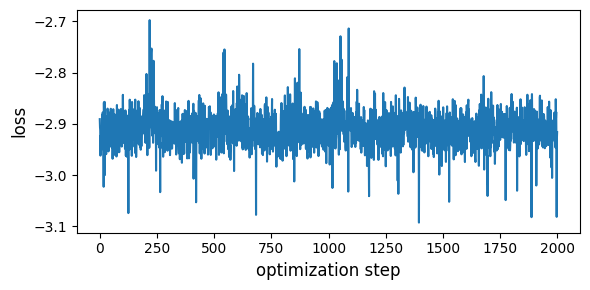

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(result.losses[-2000:])

ax.set_xlabel('optimization step', fontsize=12)
ax.set_ylabel('loss', fontsize=12)

fig.tight_layout()
plt.show()

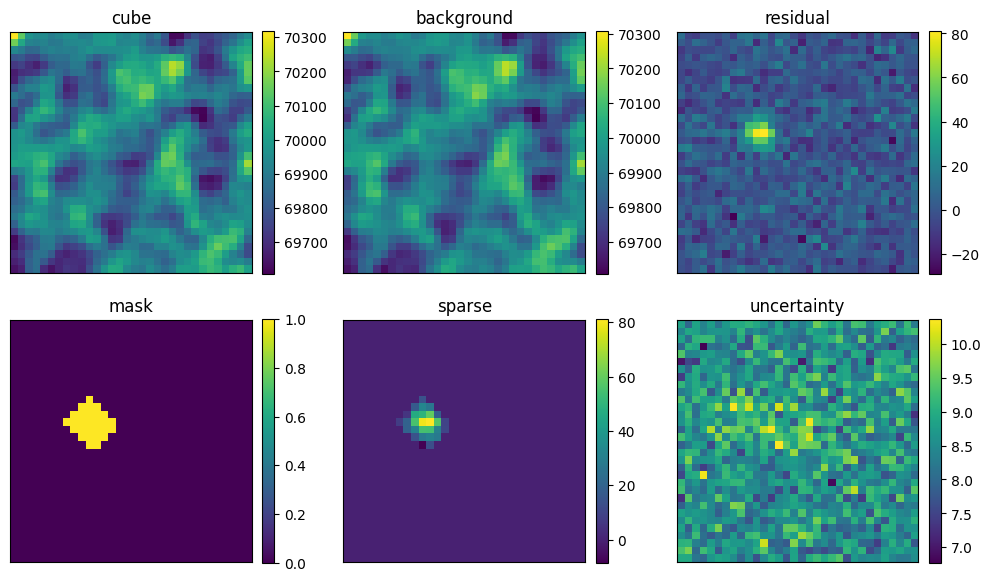

In [6]:
frame_index = 40

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
    ('cube', cube[frame_index]),
    ('background', result.background[frame_index]),
    ('residual', result.residual[frame_index]),
    ('mask', result.mask[frame_index]),
    ('sparse', result.sparse[frame_index]),
    ('uncertainty', result.uncertainty[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
    handle = axis.imshow(image, origin='lower', cmap='viridis')
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [7]:
hdul = fits.HDUList([
    fits.PrimaryHDU(data=result.residual),
    fits.ImageHDU(data=result.background, name='MODEL'),
    fits.ImageHDU(data=result.mask.astype('int16'), name='MASK'),
    fits.ImageHDU(data=result.uncertainty, name='ERROR')
])
hdul.writeto('../data/basisAE.fits', overwrite=True)

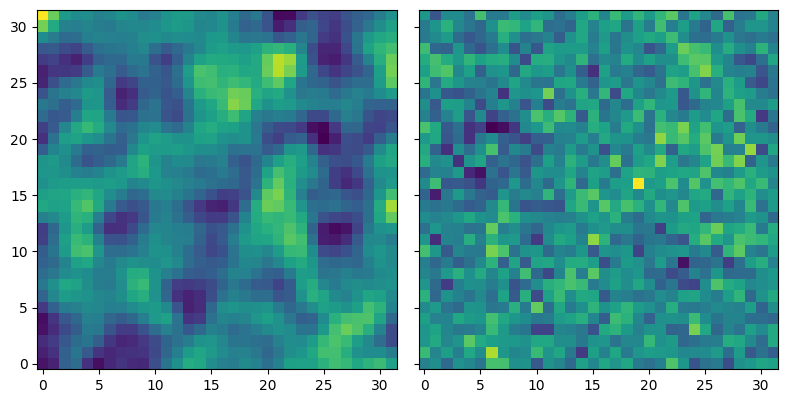

In [8]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(result.model.bias)
axes[1].imshow(result.model.basis[0])

fig.tight_layout()
plt.show()